### **Problem Statement: This assignment challenges students to construct and train a neural network to accurately classify handwritten digits from the MNIST dataset. The goal is to navigate through the preprocessing of image data, select an appropriate neural network architecture, and apply optimization techniques to achieve high classification accuracy.**

Importing the Dataset :

In [2]:
import tensorflow as tf

# Loading the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Checking the shapes of the data
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


The shape is already 28*28 so would not require the resizing ahead.



In [3]:
# checkig the labels

import numpy as np

print(np.unique(y_train))


[0 1 2 3 4 5 6 7 8 9]


In [4]:
print(np.unique(x_train))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

In [5]:
x_train.dtype

dtype('uint8')

In [6]:
print("y_train shape:", y_train.shape)
print("First 10 labels:", y_train[:10])
print("Data type of y_train:", y_train.dtype)


y_train shape: (60000,)
First 10 labels: [5 0 4 1 9 2 1 3 1 4]
Data type of y_train: uint8


In [7]:
# checking the label balance
import numpy as np

# Count occurrences of each class in y_train
unique, counts = np.unique(y_train, return_counts=True)

# Print class distribution
print("Class Distribution:", dict(zip(unique, counts)))


Class Distribution: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


<ipython-input-8-5dac40e02975>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis")


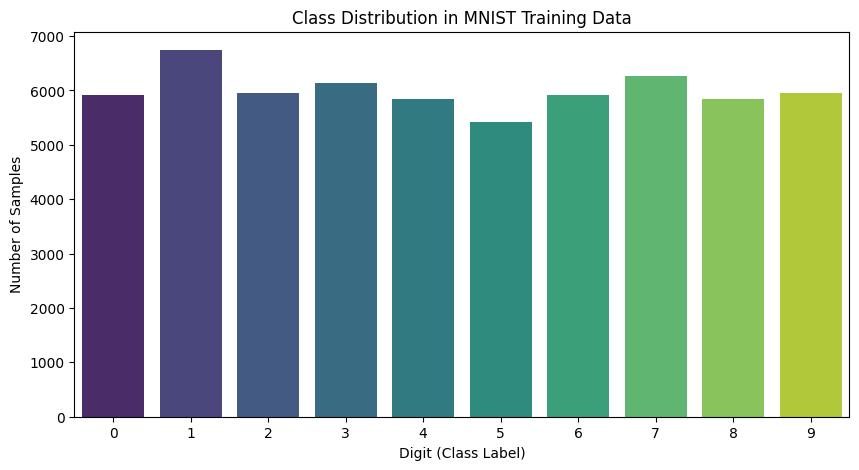

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Count occurrences dynamically
unique, counts = np.unique(y_train, return_counts=True)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=unique, y=counts, palette="viridis")

plt.xlabel("Digit (Class Label)")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in MNIST Training Data")
plt.show()


In [9]:
#normalizing the x_train and x_test

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


In [10]:
# checking the normalization.
print(np.unique(x_train))

[0.         0.00392157 0.00784314 0.01176471 0.01568628 0.01960784
 0.02352941 0.02745098 0.03137255 0.03529412 0.03921569 0.04313726
 0.04705882 0.05098039 0.05490196 0.05882353 0.0627451  0.06666667
 0.07058824 0.07450981 0.07843138 0.08235294 0.08627451 0.09019608
 0.09411765 0.09803922 0.10196079 0.10588235 0.10980392 0.11372549
 0.11764706 0.12156863 0.1254902  0.12941177 0.13333334 0.13725491
 0.14117648 0.14509805 0.14901961 0.15294118 0.15686275 0.16078432
 0.16470589 0.16862746 0.17254902 0.1764706  0.18039216 0.18431373
 0.1882353  0.19215687 0.19607843 0.2        0.20392157 0.20784314
 0.21176471 0.21568628 0.21960784 0.22352941 0.22745098 0.23137255
 0.23529412 0.23921569 0.24313726 0.24705882 0.2509804  0.25490198
 0.25882354 0.2627451  0.26666668 0.27058825 0.27450982 0.2784314
 0.28235295 0.28627452 0.2901961  0.29411766 0.29803923 0.3019608
 0.30588236 0.30980393 0.3137255  0.31764707 0.32156864 0.3254902
 0.32941177 0.33333334 0.3372549  0.34117648 0.34509805 0.3490196

In [11]:
#apply one hot encoding on the y_test and y_train

from tensorflow.keras.utils import to_categorical

# Apply one-hot encoding to the labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


In [12]:
print("Shape of y_train after OHE:", y_train.shape)
print("Shape of y_test after OHE:", y_test.shape)

# Example: Print first one-hot encoded label
print("Example One-Hot Encoded Label:", y_train[0])
print("Data type of y_test after OHE:", y_test[0])

Shape of y_train after OHE: (60000, 10)
Shape of y_test after OHE: (10000, 10)
Example One-Hot Encoded Label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Data type of y_test after OHE: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [13]:
y_train[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [14]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

### **Model Building:**

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Defining the model
model = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten 28x28 image into 1D array
    Dense(128, activation='relu'),  # First hidden layer with 128 neurons
   # Dropout(0.2),  # Add dropout layer with a dropout rate of 0.2
    Dense(64, activation='relu'),
   # Dropout(0.2), # Add dropout layer with a dropout rate of 0.2
    Dense(32, activation='relu'),
    Dense(10, activation='softmax') # Output layer with 10 neurons (digits 0-9)
])

# Compilin the model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#evaluating the performance of the model using the testing dataset ensuring that the model generalizes well to unseen data

# Train the model
model.fit(x_train, y_train, epochs=30, batch_size=64, validation_split=0.2)

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5250 - loss: 1.5864 - val_accuracy: 0.8779 - val_loss: 0.4527
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8791 - loss: 0.4292 - val_accuracy: 0.9058 - val_loss: 0.3240
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9050 - loss: 0.3284 - val_accuracy: 0.9195 - val_loss: 0.2798
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9193 - loss: 0.2849 - val_accuracy: 0.9250 - val_loss: 0.2541
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9284 - loss: 0.2479 - val_accuracy: 0.9326 - val_loss: 0.2332
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9317 - loss: 0.2356 - val_accuracy: 0.9371 - val_loss: 0.2170
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9398 - loss: 0.2090 - val_accuracy: 0.9414 - val_loss: 0.2032
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9420 - loss: 0.1976 - val_accuracy: 0.

### The above hyper parameter setting is refined to get the desired level of accuracy.

In [17]:
import numpy as np

def predict_image(image):

    # Ensure the input is a NumPy array
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    # If a single image is provided (28x28), convert it to a batch format (1, 28, 28)
    if image.ndim == 2:
        image = np.expand_dims(image, axis=0)

    # Validate input shape
    if image.shape[1:] != (28, 28):
        raise ValueError("Input image(s) must have shape (28, 28) or (batch_size, 28, 28)")

    # Normalize image data to match the training input (if needed)
    image = image.astype("float32") / 255.0  # Scale pixel values to [0, 1]

    # Make predictions
    predictions = model.predict(image)

    # Get the predicted class with the highest probability
    predicted_classes = np.argmax(predictions, axis=1)

    return predicted_classes


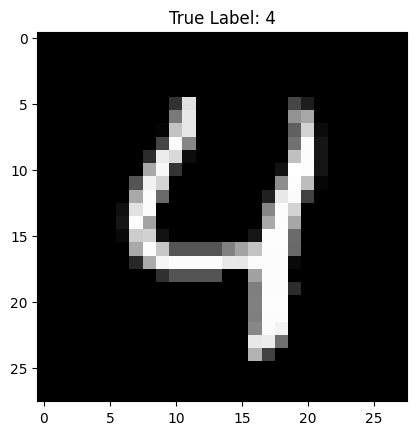

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Class: 4


In [18]:
# to predict a single image from mnist dataset
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(_, _), (x_test, y_test) = mnist.load_data()

# Select an image for testing
index = 4  # Change this index to test different images
test_image = x_test[index]
true_label = y_test[index]

# Show the image
plt.imshow(test_image, cmap='gray')
plt.title(f"True Label: {true_label}")
plt.show()

# Predict the digit
predicted_class = predict_image(test_image)
print(f"Predicted Class: {predicted_class[0]}")


In [19]:
# Select a batch of 10 images
batch_images = x_test[:7]

# Get predictions
predicted_classes = predict_image(batch_images)

# Print results
print("Predicted Classes:", predicted_classes)
print("True Labels:", y_test[:7])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Classes: [7 2 1 0 4 1 4]
True Labels: [7 2 1 0 4 1 4]


In [20]:
# Checking prediction for a custom image (unseen data)
import cv2

# Load a grayscale image (custom handwritten digit)
image_path = "/content/drive/MyDrive/For Collab/Quiz_and_assignments/sample_mnist_image.png"  # Provide the path to your image
custom_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Resize to (28, 28) if necessary
custom_image = cv2.resize(custom_image, (28, 28))

# Invert colors if needed (MNIST has white digits on black background)
custom_image = 255 - custom_image


# Predict the digit
predicted_class = predict_image(custom_image)
print(f"Predicted Class: {predicted_class[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Class: 8


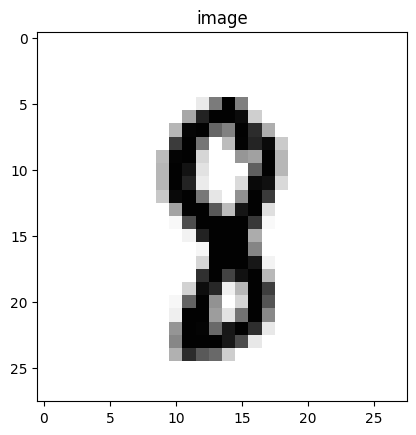

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Raw Logits:
Label 0: 0.04027679190039635
Label 1: 1.0300114094974333e-09
Label 2: 2.172965650970582e-05
Label 3: 3.879848406995734e-07
Label 4: 3.274301363376253e-08
Label 5: 1.0098681002546073e-08
Label 6: 1.357386736344779e-07
Label 7: 2.0386502815744612e-13
Label 8: 0.9596814513206482
Label 9: 1.9472487110760994e-05


In [32]:
#checking the raw logits

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import cv2


image_path = "/content/drive/MyDrive/For Collab/Quiz_and_assignments/sample_eig.png"
custom_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Resize to (28, 28) if necessary
custom_image = cv2.resize(custom_image, (28, 28))

#inverting the pixel color

custom_image = 255-custom_image

# Show the image
plt.imshow(custom_image, cmap='gray')
plt.title(f"image")
plt.show()
# Reshape and normalize the image for prediction
input_image = np.expand_dims(custom_image, axis=0)
input_image = input_image.astype("float32") / 255.0

# Get raw logits
predictions = model.predict(input_image)

# Print raw logits for each label
print("Raw Logits:")
for i, logit in enumerate(predictions[0]):
  print(f"Label {i}: {logit}")

